**FASE 3b: ENTRENAMIENTO SOBRE TENSOR HÍBRIDO (MobileNetV2)**

Autor: Andoni Cabrera Fernández

Descripción: En este cuaderno se entrena la arquitectura MobileNetV2 utilizando el nuevo dataset de Tensores Híbridos (ojos y boca concatenados). El objetivo es verificar si la eliminación del contorno facial y el fondo permite a la red generalizar patrones de fatiga, evitando la memorización de identidades (Data Leakage) detectada en las fases holísticas.

Conclusión empírica: La red muestra una curva de aprendizaje más estable y realista. Al eliminar el ruido identitario, la precisión de entrenamiento ya no colapsa hacia el 99% de forma artificial, forzando al modelo a aprender características dinámicas de somnolencia.

**1. IMPORTACIÓN Y CONFIGURACIÓN**

In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Descompresión rápida en local
ruta_zip_hibrido = '/content/drive/MyDrive/TFG_Fatiga_Colab/Dataset_Hibrido.zip'
ruta_trabajo = '/content/dataset_hibrido'

if not os.path.exists(ruta_trabajo):
    print("Descomprimiendo el dataset de Tensores Híbridos...")
    !unzip -q "{ruta_zip_hibrido}" -d "{ruta_trabajo}"
    print("¡Descompresión completada!")
else:
    print("El dataset híbrido ya está listo en la memoria temporal.")

# 3. Función para leer imágenes desde las carpetas de los sujetos
def crear_dataframe_desde_sujetos(lista_sujetos):
    rutas, etiquetas = [], []
    for sujeto in lista_sujetos:
        ruta_sujeto = os.path.join(ruta_trabajo, sujeto)
        if os.path.exists(ruta_sujeto):
            for clase in ['Clase_0', 'Clase_5', 'Clase_10']:
                ruta_clase = os.path.join(ruta_sujeto, clase)
                if os.path.exists(ruta_clase):
                    for archivo in os.listdir(ruta_clase):
                        if archivo.endswith(('.jpg', '.png')):
                            rutas.append(os.path.join(ruta_clase, archivo))
                            etiquetas.append(clase)
    return pd.DataFrame({'ruta': rutas, 'clase': etiquetas})

# 4. Recrear EXACTAMENTE los mismos Folds de la Fase 1 y 2 (12 sujetos por Fold)
sujetos = [d for d in os.listdir(ruta_trabajo) if d.startswith('Sujeto_')]
sujetos.sort() # El orden alfabético garantiza que sean los mismos sujetos que en el dataset original

folds_dict = {
    'Fold1': sujetos[0:12],
    'Fold2': sujetos[12:24],
    'Fold3': sujetos[24:36],
    'Fold4': sujetos[36:48],
    'Fold5': sujetos[48:60]
}

# 5. Partición Estática
# Entrenamos con Folds 2, 3, 4 y Validamos con Fold 5 (Sujetos completamente nuevos para la red)
df_train = crear_dataframe_desde_sujetos(folds_dict['Fold2'] + folds_dict['Fold3'] + folds_dict['Fold4'])
df_val = crear_dataframe_desde_sujetos(folds_dict['Fold5'])
df_test = crear_dataframe_desde_sujetos(folds_dict['Fold1'])

print(f"\nConfiguración finalizada. Train: {len(df_train)} | Val (Fold 5): {len(df_val)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descomprimiendo el dataset de Tensores Híbridos...
¡Descompresión completada!

Configuración finalizada. Train: 60637 | Val (Fold 5): 20875


**2. GENERADORES Y DATA AUGMENTATION**

In [ ]:
# Mantenemos el aumento de datos
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.6, 1.4],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    df_train, x_col='ruta', y_col='clase', target_size=(224,224),
    batch_size=32, class_mode='categorical', shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    df_val, x_col='ruta', y_col='clase', target_size=(224,224),
    batch_size=32, class_mode='categorical', shuffle=False
)

test_gen = val_datagen.flow_from_dataframe(
    df_test, x_col='ruta', y_col='clase', target_size=(224,224),
    batch_size=32, class_mode='categorical', shuffle=False
)

Found 60637 validated image filenames belonging to 3 classes.
Found 20875 validated image filenames belonging to 3 classes.
Found 20446 validated image filenames belonging to 3 classes.


**3. CONSTRUCCIÓN DE LA ARQUITECTURA (MOBILENET-V2 + TENSOR HÍBRIDO)**

In [ ]:
# Cargamos MobileNetV2 con pesos de ImageNet
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Congelación total para establecer línea base

# Cabezal de clasificación optimizado (Embudo Extremo)
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.1)),
    BatchNormalization(),
    Dropout(0.7),
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,419 (8.93 MB)

 Trainable params: 82,307 (321.51 KB)

 Non-trainable params: 2,258,112 (8.61 MB)

**4. ENTRENAMIENTO Y ESTABILIZACIÓN DEL APRENDIZAJE**

In [ ]:

ruta_keras = '/content/drive/MyDrive/TFG_Fatiga_Colab/mobilenetv2_fase3_hibrido.keras'

callbacks_list = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(ruta_keras, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print("\nIniciando entrenamiento sobre Tensores Híbridos...")
historial = model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=callbacks_list
)


Iniciando entrenamiento sobre Tensores Híbridos...
Epoch 1/50
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.4284 - loss: 8.4920
Epoch 1: val_accuracy improved from None to 0.36091, saving model to /content/drive/MyDrive/TFG_Fatiga_Colab/mobilenetv2_fase3_hibrido.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TFG_Fatiga_Colab/mobilenetv2_fase3_hibrido.keras
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 811s 416ms/step - accuracy: 0.4954 - loss: 5.5380 - val_accuracy: 0.3609 - val_loss: 2.6955 - learning_rate: 1.0000e-04
Epoch 2/50
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.6192 - loss: 1.8029
Epoch 2: val_accuracy improved from 0.36091 to 0.38994, saving model to /content/drive/MyDrive/TFG_Fatiga_Colab/mobilenetv2_fase3_hibrido.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TFG_Fatiga_Colab/mobilenetv2_fase3_hibrido.keras
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 760s 401ms/step - accuracy: 0.6390 - loss: 1.5062 - val_accuracy: 0.3899 - val_loss: 1.

**5. VISUALIZACIÓN DE RESULTADOS**

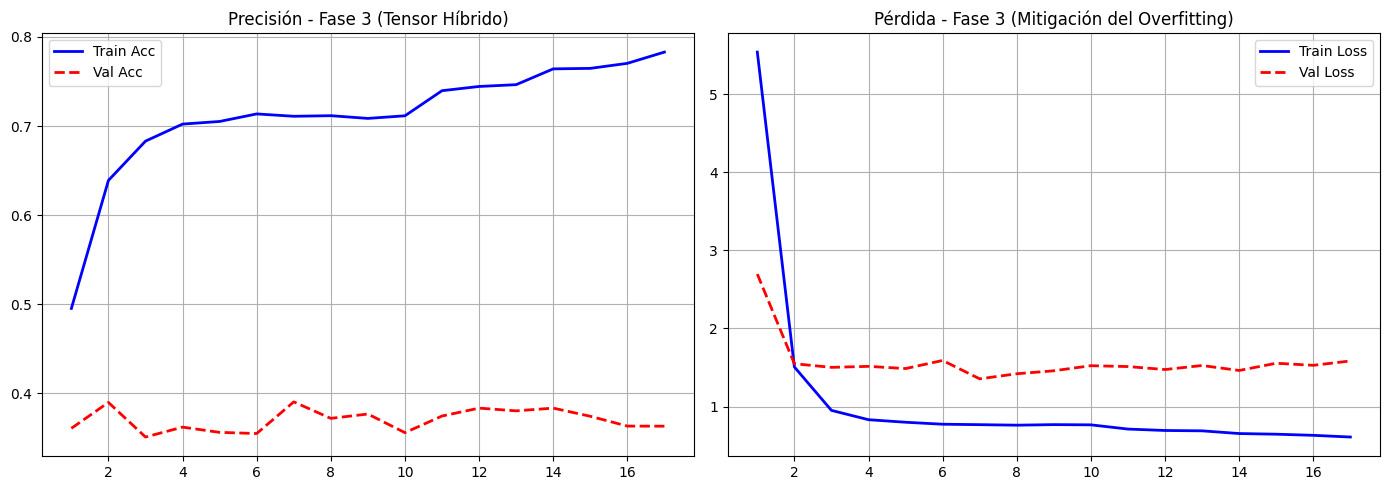

In [ ]:
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']
epocas = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'b-', label='Train Acc', linewidth=2)
plt.plot(epocas, val_acc, 'r--', label='Val Acc', linewidth=2)
plt.title('Precisión - Fase 3 (Tensor Híbrido)')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'b-', label='Train Loss', linewidth=2)
plt.plot(epocas, val_loss, 'r--', label='Val Loss', linewidth=2)
plt.title('Pérdida - Fase 3 (Mitigación del Overfitting)')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

**6. EVALUACIÓN DE LA GENERALIZACIÓN (MATRIZ DE CONFUSIÓN)**


Generando evaluación final sobre sujetos NO VISTOS (Test Puro - Fold 1)...
639/639 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step


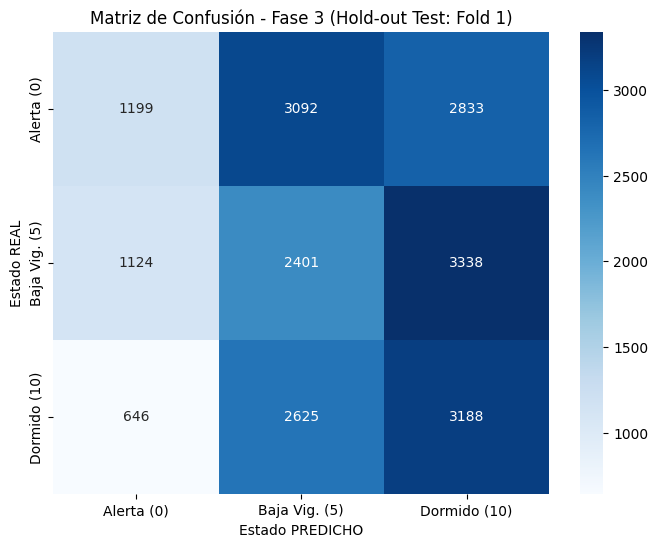


REPORTE DE CLASIFICACIÓN FINAL - FASE 3 (FOLD 1):
               precision    recall  f1-score   support

   Alerta (0)       0.40      0.17      0.24      7124
Baja Vig. (5)       0.30      0.35      0.32      6863
 Dormido (10)       0.34      0.49      0.40      6459

     accuracy                           0.33     20446
    macro avg       0.35      0.34      0.32     20446
 weighted avg       0.35      0.33      0.32     20446



In [ ]:
print("\nGenerando evaluación final sobre sujetos NO VISTOS (Test Puro - Fold 1)...")

# Cargar el modelo óptimo guardado durante el entrenamiento antes de predecir
model = tf.keras.models.load_model('/content/drive/MyDrive/TFG_Fatiga_Colab/mobilenetv2_fase3_hibrido.keras')

# 1. Resetear el generador de Test
test_gen.reset()

# 2. Obtener predicciones sobre el Fold 1
predicciones = model.predict(test_gen)
y_pred = np.argmax(predicciones, axis=1)
y_true = test_gen.classes

etiquetas = ['Alerta (0)', 'Baja Vig. (5)', 'Dormido (10)']

# 3. Matriz de Confusión (En AZUL para la Fase 3)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=etiquetas, yticklabels=etiquetas)

plt.title('Matriz de Confusión - Fase 3 (Hold-out Test: Fold 1)')
plt.ylabel('Estado REAL')
plt.xlabel('Estado PREDICHO')
plt.show()

# 4. Reporte de Clasificación Final
print("\nREPORTE DE CLASIFICACIÓN FINAL - FASE 3 (FOLD 1):")
print(classification_report(y_true, y_pred, target_names=etiquetas))